# Compensation Evidence: What the Dataset Can and Cannot Support

## Decision Question

What compensation comparisons are defensible given the dataset's salary coverage?

The central analytical issue is salary missingness. Only **582 India postings (1.1%)** disclose annual salary, including **94 Data Analyst postings (1.5%)**. Salary figures are therefore treated as directional evidence from the disclosed subset, not as market benchmarks.

In [1]:
import ast

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import FuncFormatter

In [2]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])


def parse_skills(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    if isinstance(value, list):
        return value
    return []


df["job_skills"] = df["job_skills"].apply(parse_skills)

india_jobs = df[df["job_country"] == "India"].copy()

salary_market = india_jobs.dropna(subset=["salary_year_avg"]).copy()

print(f"Total dataset postings: {len(df):,}")
print(f"India postings: {len(india_jobs):,}")
print(f"Analysis year: {india_jobs['job_posted_date'].dt.year.mode()[0]}")

assert not india_jobs.empty
assert india_jobs["job_country"].eq("India").all()
assert india_jobs["job_posted_date"].dt.year.nunique() == 1

Total dataset postings: 785,741
India postings: 51,088
Analysis year: 2023


In [3]:
# Notebook-wide visualization settings

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "figure.titlesize": 16,
    "figure.dpi": 110
})

## Disclosure Coverage by Role

**Coverage** is the share of a role's postings with annual salary. A role can have a seemingly precise median while still having weak coverage; both sample size and coverage must be visible.

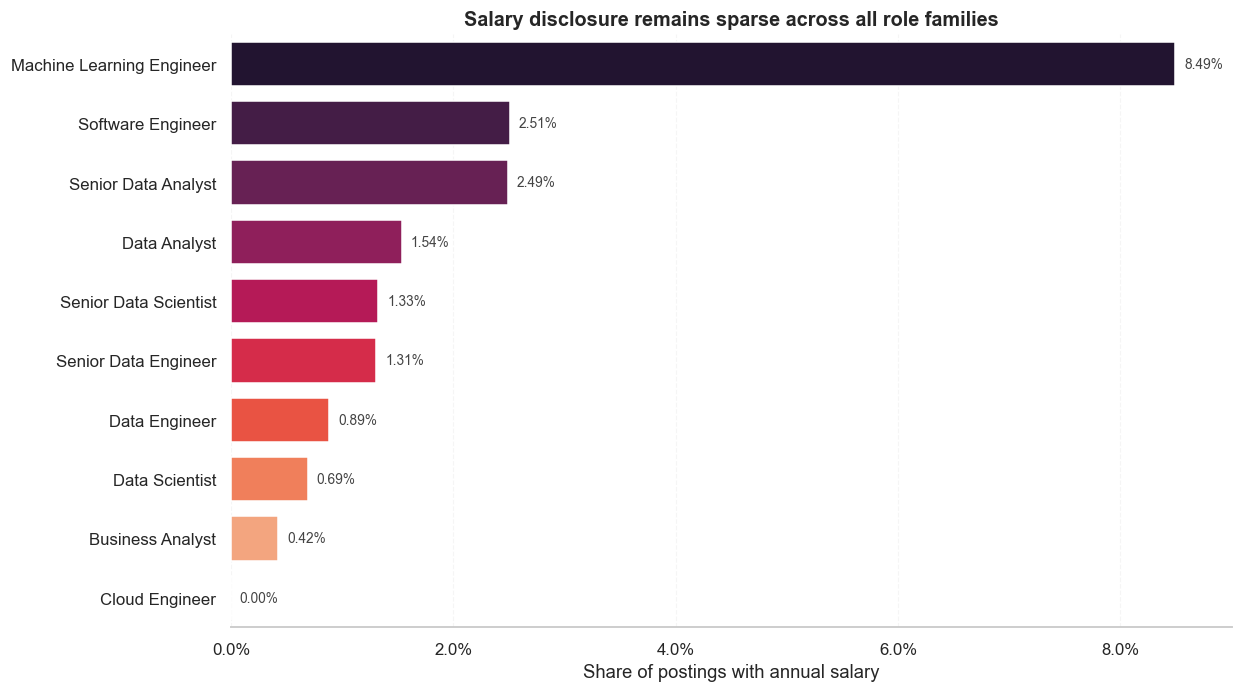

Role,Postings,Salary Records,Coverage
Data Engineer,"19,062",169,0.89%
Data Analyst,"6,121",94,1.54%
Data Scientist,"13,279",92,0.69%
Machine Learning Engineer,671,57,8.49%
Senior Data Engineer,"4,353",57,1.31%
Software Engineer,"1,795",45,2.51%
Senior Data Scientist,"2,486",33,1.33%
Senior Data Analyst,"1,083",27,2.49%
Business Analyst,"1,887",8,0.42%
Cloud Engineer,351,0,0.00%


In [4]:
coverage_by_role = (
    india_jobs.groupby("job_title_short")
    .agg(
        postings=("job_title_short", "size"),
        salary_records=("salary_year_avg", "count"),
    )
)

coverage_by_role["coverage"] = (
    coverage_by_role["salary_records"] / coverage_by_role["postings"]
)

coverage_by_role = coverage_by_role.sort_values(
    "coverage",
    ascending=False,
)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

sns.barplot(
    data=coverage_by_role.reset_index(),
    x="coverage",
    y="job_title_short",
    hue="coverage",
    palette=sns.color_palette("rocket_r", n_colors=len(coverage_by_role)),
    legend=False,
    saturation=0.95,
    width=0.75,
    ax=ax,
)

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(0, coverage_by_role["coverage"].max() * 1.06)

ax.set(
    title="Salary disclosure remains sparse across all role families",
    xlabel="Share of postings with annual salary",
    ylabel="",
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.18,
)
ax.grid(axis="y", visible=False)

for bar in ax.patches:
    value = bar.get_width()

    ax.text(
        value + 0.0008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2%}",
        va="center",
        ha="left",
        fontsize=9,
        color="#444444",
    )

sns.despine(left=True, top=True, right=True)

plt.tight_layout(pad=1.2)
plt.show()

coverage_table = (
    coverage_by_role
    .rename_axis("Role")
    .reset_index()
    .rename(
        columns={
            "postings": "Postings",
            "salary_records": "Salary Records",
            "coverage": "Coverage",
        }
    )
    .sort_values(
        "Salary Records",
        ascending=False,
    )
)

display(
    coverage_table.style
    .format(
        {
            "Postings": "{:,}",
            "Salary Records": "{:,}",
            "Coverage": "{:.2%}",
        }
    )
    .hide(axis="index")
)

No role has enough disclosure coverage to represent the full market confidently. The disclosed sample is useful for hypothesis generation, but the missing salaries are not demonstrably random.

## Selection Bias in the Disclosed Subset

The representation gap compares each role's share of salary-disclosed postings with its share of all India postings. A positive gap means the role is overrepresented in the salary evidence.

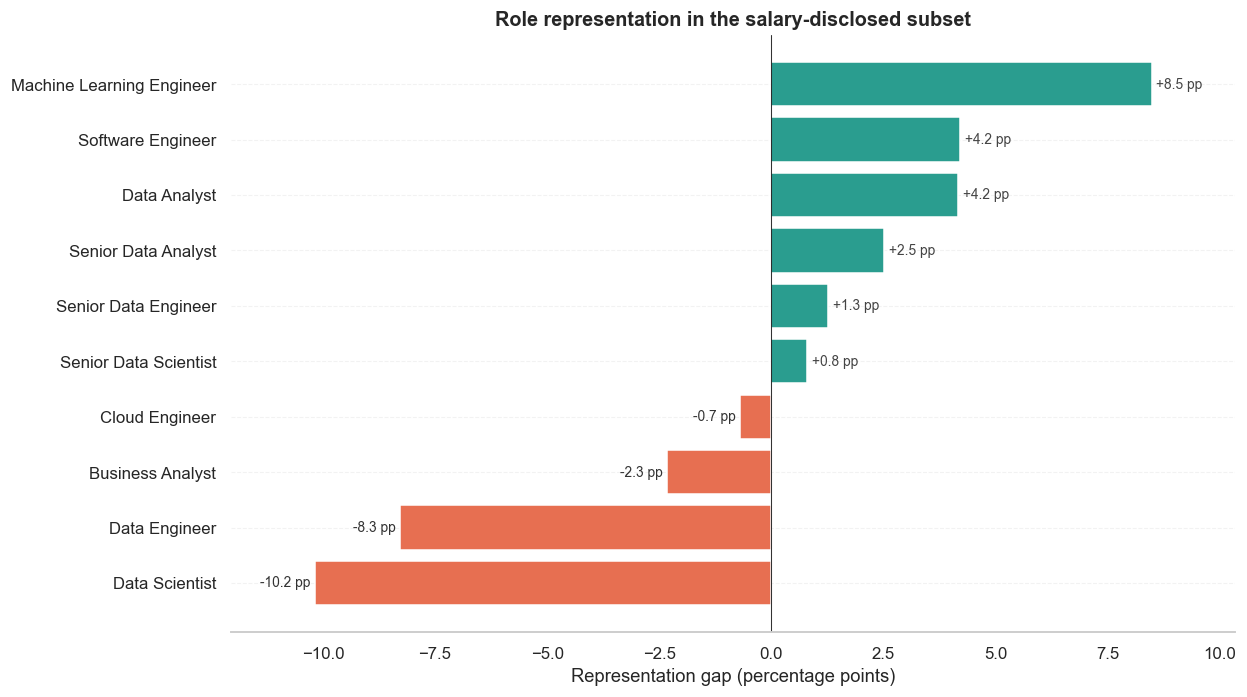

Rank,Role,All Postings,Salary Subset,Representation Gap (pp)
1,Machine Learning Engineer,1.3%,9.8%,+8.5 pp
2,Software Engineer,3.5%,7.7%,+4.2 pp
3,Data Analyst,12.0%,16.2%,+4.2 pp
4,Senior Data Analyst,2.1%,4.6%,+2.5 pp
5,Senior Data Engineer,8.5%,9.8%,+1.3 pp
6,Senior Data Scientist,4.9%,5.7%,+0.8 pp
7,Cloud Engineer,0.7%,0.0%,-0.7 pp
8,Business Analyst,3.7%,1.4%,-2.3 pp
9,Data Engineer,37.3%,29.0%,-8.3 pp
10,Data Scientist,26.0%,15.8%,-10.2 pp


In [5]:
# Overall role share in all India postings
all_role_share = (
    india_jobs["job_title_short"]
    .value_counts(normalize=True)
)

# Role share among salary-disclosed postings
salary_role_share = (
    salary_market["job_title_short"]
    .value_counts(normalize=True)
)

bias = pd.concat(
    [
        all_role_share.rename("All Postings"),
        salary_role_share.rename("Salary Subset"),
    ],
    axis=1,
).fillna(0)

bias["Representation Gap (pp)"] = (
    (bias["Salary Subset"] - bias["All Postings"]) * 100
)

bias = bias.sort_values("Representation Gap (pp)")

# -------------------------------------------------------------------
# Chart
# -------------------------------------------------------------------

colors = [
    "#2A9D8F" if value > 0 else "#E76F51"
    for value in bias["Representation Gap (pp)"]
]

fig, ax = plt.subplots(figsize=(11.5, 6.5))

bars = ax.barh(
    bias.index,
    bias["Representation Gap (pp)"],
    color=colors,
)

# Value labels
for bar in bars:

    width = bar.get_width()

    if width >= 0:
        ax.text(
            width + 0.10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:+.1f} pp",
            va="center",
            fontsize=9,
            color="#444444",
        )

    else:
        ax.text(
            width - 0.10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:+.1f} pp",
            ha="right",
            va="center",
            fontsize=9,
            color="#333333",
        )

# Zero reference line
ax.axvline(
    0,
    color="black",
    linewidth=0.7,
    alpha=0.8,
)

ax.set(
    title="Role representation in the salary-disclosed subset",
    xlabel="Representation gap (percentage points)",
    ylabel="",
)

# Horizontal grid only
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.grid(False, axis="x")

sns.despine(
    top=True,
    right=True,
    left=True,
    bottom=False,
)

ax.set_axisbelow(True)

ax.margins(x=0.10)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Summary table
# -------------------------------------------------------------------

display_table = (
    bias.sort_values(
        "Representation Gap (pp)",
        ascending=False,
    )
    .reset_index()
    .rename(
        columns={
            "job_title_short": "Role",
        }
    )
)

display_table.insert(
    0,
    "Rank",
    range(1, len(display_table) + 1),
)

display(
    display_table.style
    .format(
        {
            "All Postings": "{:.1%}",
            "Salary Subset": "{:.1%}",
            "Representation Gap (pp)": "{:+.1f} pp",
        }
    )
    .hide(axis="index")
)

The salary subset does not preserve the role mix of the full market. That selection effect weakens comparisons based solely on pooled salary records and makes role-level sample thresholds essential.

## Directional Role Comparisons

The chart includes only roles with at least 20 salary records. Medians are shown with interquartile ranges to make dispersion visible; they remain estimates of the disclosed subset.

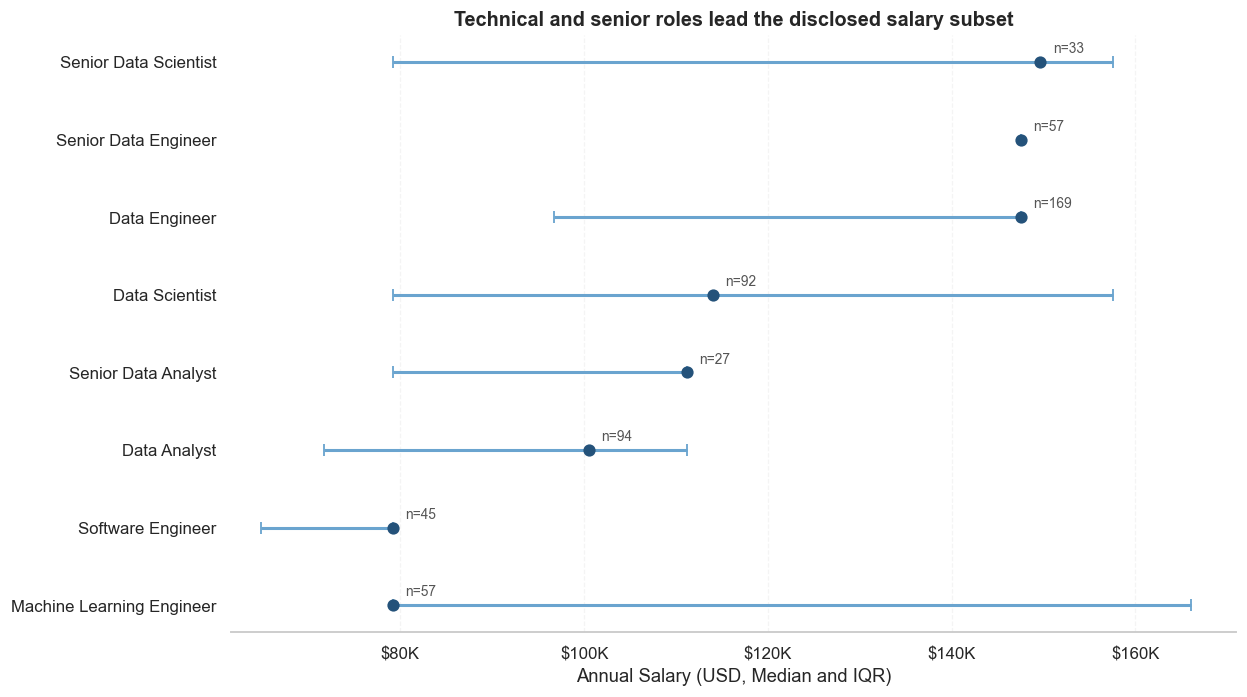

Rank,Role,Disclosed Salaries,Median Salary,25th Percentile,75th Percentile
1,Senior Data Scientist,33,"$149,653","$79,200","$157,500"
2,Data Engineer,169,"$147,500","$96,773","$147,500"
3,Senior Data Engineer,57,"$147,500","$147,500","$147,500"
4,Data Scientist,92,"$114,008","$79,200","$157,500"
5,Senior Data Analyst,27,"$111,175","$79,200","$111,175"
6,Data Analyst,94,"$100,500","$71,700","$111,175"
7,Machine Learning Engineer,57,"$79,200","$79,200","$166,000"
8,Software Engineer,45,"$79,200","$64,800","$79,200"


In [6]:
# -------------------------------------------------------------------
# Median salary and IQR by role
# -------------------------------------------------------------------

role_salary = (
    salary_market.groupby("job_title_short")["salary_year_avg"]
    .agg(
        salary_records="count",
        median_salary="median",
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75),
    )
)

role_salary = (
    role_salary[
        role_salary["salary_records"] >= 20
    ]
    .sort_values("median_salary")
)

# -------------------------------------------------------------------
# Chart
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11.5, 6.5))

xerr = [
    role_salary["median_salary"] - role_salary["q1"],
    role_salary["q3"] - role_salary["median_salary"],
]

ax.errorbar(
    role_salary["median_salary"],
    role_salary.index,
    xerr=xerr,
    fmt="o",
    markersize=7,
    color="#24527a",
    ecolor="#6aa4cf",
    elinewidth=2,
    capsize=4,
    capthick=1.2,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"${value / 1_000:,.0f}K")
)

ax.set(
    title="Technical and senior roles lead the disclosed salary subset",
    xlabel="Annual Salary (USD, Median and IQR)",
    ylabel="",
)

# Sample-size labels
for role, row in role_salary.iterrows():

    ax.annotate(
        f"n={int(row['salary_records'])}",
        (row["median_salary"], role),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=9,
        color="#555555",
    )

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.20,
)

ax.grid(False, axis="y")

sns.despine(
    top=True,
    right=True,
    left=True,
    bottom=False,
)

ax.set_axisbelow(True)

ax.set_xlim(
    role_salary["q1"].min() * 0.95,
    role_salary["q3"].max() * 1.03,
)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Display table
# -------------------------------------------------------------------

display_table = (
    role_salary
    .sort_values(
        "median_salary",
        ascending=False,
    )
    .reset_index()
    .rename(
        columns={
            "job_title_short": "Role",
            "salary_records": "Disclosed Salaries",
            "median_salary": "Median Salary",
            "q1": "25th Percentile",
            "q3": "75th Percentile",
        }
    )
)

display_table.insert(
    0,
    "Rank",
    range(1, len(display_table) + 1),
)

display(
    display_table.style
    .format(
        {
            "Median Salary": "${:,.0f}",
            "25th Percentile": "${:,.0f}",
            "75th Percentile": "${:,.0f}",
        }
    )
    .hide(axis="index")
)

Within the disclosed subset, Senior Data Scientist has the highest median among roles clearing the sample threshold, while Data Engineer and Senior Data Engineer both have median disclosed salaries near $147.5K. Data Analyst's disclosed median is about $100.5K. These values should not be read as typical India salaries because disclosure is sparse and the dataset standardizes pay to annual USD.

## Implications

- Use the salary analysis to compare the disclosed subset, not to quote market benchmarks.
- Pair every compensation figure with sample size, coverage, and dispersion.
- Treat differences as signals for further validation with a dedicated compensation source.

## Limitations

- Salary is missing for 98.9% of India postings and may be missing systematically.
- Annual USD standardization may obscure local compensation structures.
- The dataset does not control for seniority, location, employer, or experience within role families.
- Repeated identical salary values suggest that some figures may be estimates or standardized inputs rather than employer-disclosed amounts.